## Analysis / Evaluation 
This notebook is for producing graphs for the final report.
We created an evaulation.py file for certain graph generation, but rather than updating it, for convenience and time we are using this notebook

In [39]:
from music21 import converter
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from collections import Counter
import music21
import pandas as pd
import glob
import os

In [40]:
def analyze_midi_file(filepath):
    score = converter.parse(filepath)

    pitches = []
    durations = []
    for note in score.flatten().notes:
        if note.isNote:
            pitches.append(note.pitch.midi)
            durations.append(note.quarterLength)

    if len(pitches) < 2:
        return None

    intervals = [pitches[i+1] - pitches[i] for i in range(len(pitches) - 1)]

    return pitches, durations, intervals
            

def extract_data(dirpath, max_files=None):
    all_pitches = []
    all_durations = []
    all_intervals = []
    
    files_processed = 0
    for filename in os.listdir(dirpath):
        if max_files and files_processed >= max_files:
            break
            
        if filename.endswith('.mid') or filename.endswith('.midi'):
            filepath = os.path.join(dirpath, filename)
            try:
                result = analyze_midi_file(filepath)
                if result is not None:
                    pitches, durations, intervals = result
                    all_pitches.extend(pitches)
                    all_durations.extend(durations)
                    all_intervals.extend(intervals)
                    files_processed += 1
            except Exception as e:
                print(f"Error processing {filename}: {e}")
    return all_pitches, all_durations, all_intervals

## Model Order Comparison

In [41]:
first_order_pitches, first_order_durations, first_order_intervals = extract_data("../outputs/classical_root_first", max_files=100)
first_avg = np.mean(np.abs(first_order_intervals))
first_stepwise_count = sum(1 for i in first_order_intervals if abs(i) <= 2)
first_pct = (first_stepwise_count / len(first_order_intervals)) * 100

In [42]:
second_order_pitches, second_order_durations, second_order_intervals = extract_data("../outputs/classical_root_second", max_files=100)
second_avg = np.mean(np.abs(second_order_intervals))
second_stepwise_count = sum(1 for i in second_order_intervals if abs(i) <= 2)
second_pct = (second_stepwise_count / len(second_order_intervals)) * 100

In [43]:
original_pitches, original_durations, original_intervals = extract_data('../data/raw/classical', max_files=50)
original_avg = np.mean(np.abs(original_intervals))
original_stepwise_count = sum(1 for i in original_intervals if abs(i) <= 2)
original_pct = (original_stepwise_count / len(original_intervals)) * 100


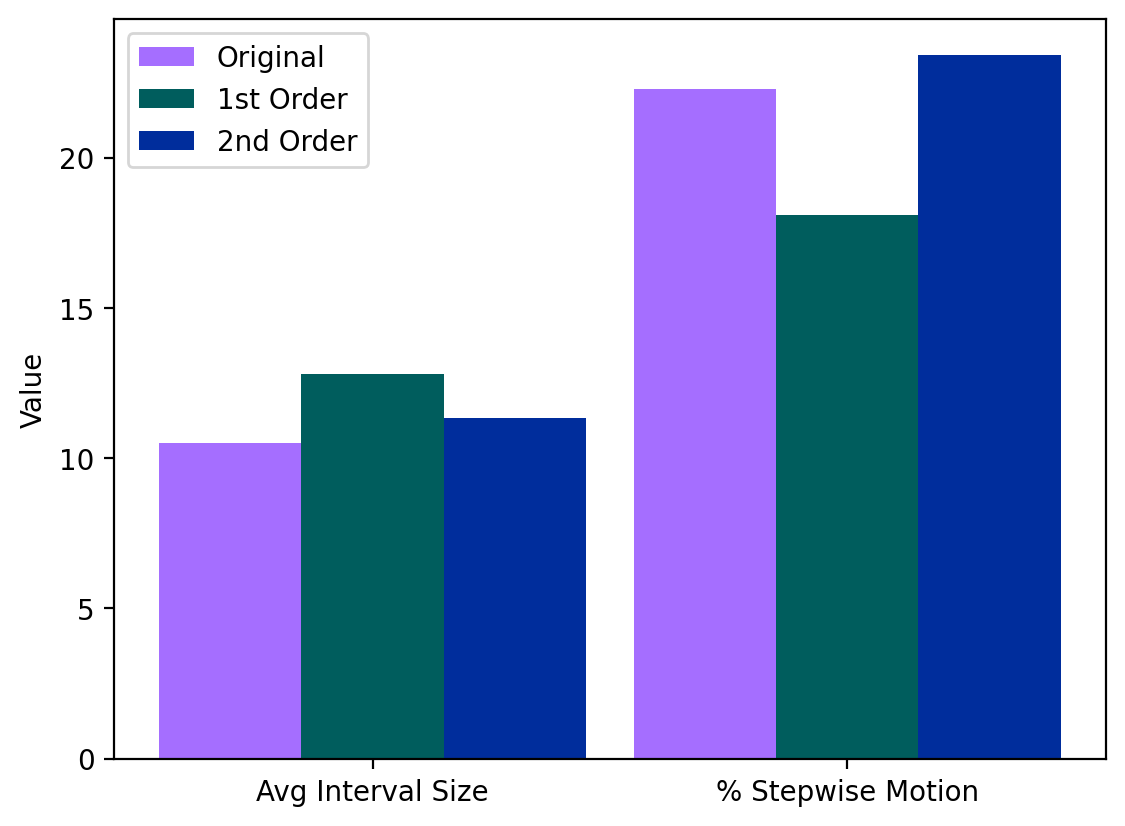

In [44]:
metrics = ['Avg Interval Size', '% Stepwise Motion']
original_vals = [original_avg, original_pct]
first_vals = [first_avg, first_pct]
second_vals = [second_avg, second_pct]

x = range(len(metrics))
plt.bar([i-0.3 for i in x], original_vals, width=0.3, label='Original', color='#a56eff')
plt.bar([i for i in x], first_vals, width=0.3, label='1st Order', color='#005d5d')
plt.bar([i+0.3 for i in x], second_vals, width=0.3, label='2nd Order', color='#002d9c')
plt.xticks(x, metrics)
plt.legend()
plt.ylabel('Value')
plt.savefig('../evaluation/order_comparison_barchart.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
print(f"Original avg: {original_avg}, stepwise: {original_pct}%")
print(f"First avg: {first_avg}, stepwise: {first_pct}%")  
print(f"Second avg: {second_avg}, stepwise: {second_pct}%")
print(f"\nOriginal intervals analyzed: {len(original_intervals)}")
print(f"First intervals analyzed: {len(first_order_intervals)}")
print(f"Second intervals analyzed: {len(second_order_intervals)}")

Original avg: 10.496441685893478, stepwise: 22.277645988366427%
First avg: 12.783971434239238, stepwise: 18.081729815512794%
Second avg: 11.33579912481767, stepwise: 23.431964992706813%

Original intervals analyzed: 61546
First intervals analyzed: 10082
Second intervals analyzed: 9598


## Effects of Constraints

In [46]:
in_key_pitches, _, in_key_intervals = extract_data("../outputs/classical_root_second/C_major", max_files=100)

Without key constraint:


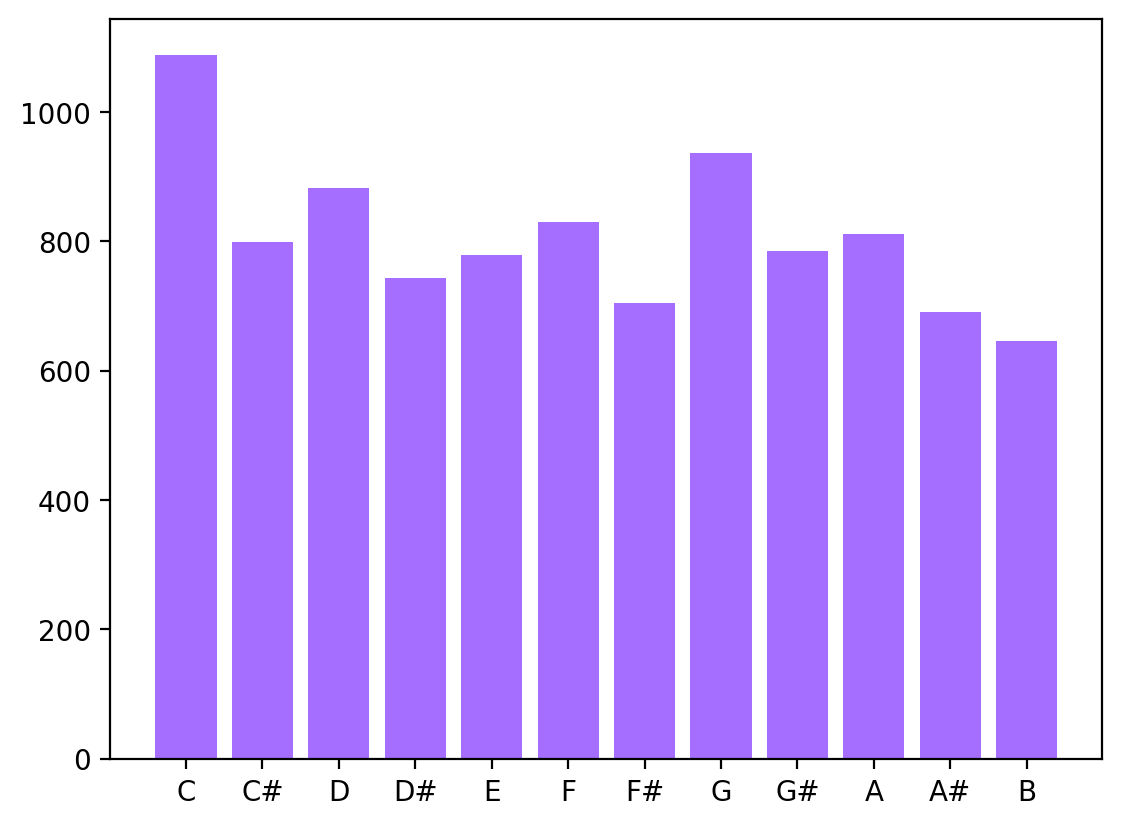

In [47]:
without_pitch_classes = [p % 12 for p in second_order_pitches if p != -1]
without_counts = Counter(without_pitch_classes)

print("Without key constraint:")
plt.bar(range(12), [without_counts[i] for i in range(12)], color='#a56eff')
_ = plt.xticks(range(12), ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B'])
plt.savefig('../evaluation/without_key_dist.png', dpi=300, bbox_inches='tight')

With key constraint:


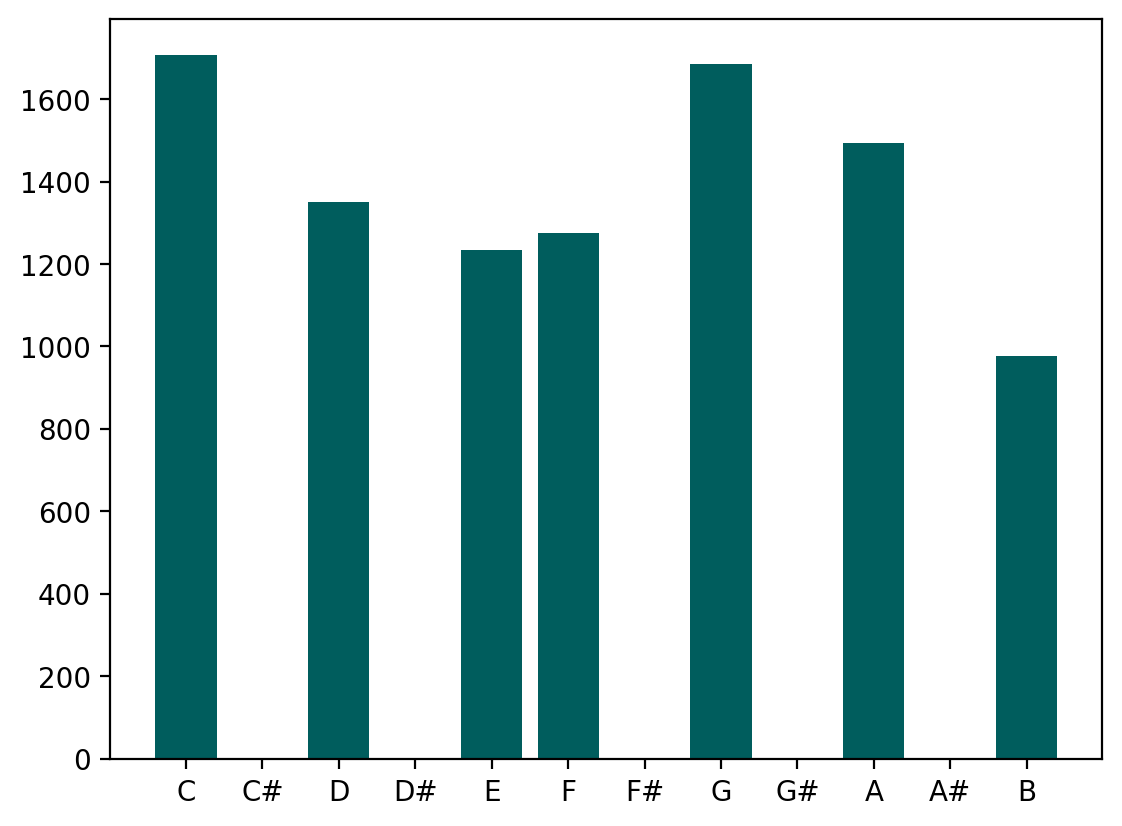

In [48]:
with_pitch_classes = [p % 12 for p in in_key_pitches if p != -1]
with_counts = Counter(with_pitch_classes)

print("With key constraint:")
plt.bar(range(12), [with_counts[i] for i in range(12)], color='#005d5d')
_ = plt.xticks(range(12), ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B'])
plt.savefig('../evaluation/with_key_dist.png', dpi=300, bbox_inches='tight')

In [49]:
fast_pitches, fast_durations, fast_intervals = extract_data("../outputs/classical_root_second/fast", max_files=100)


In [50]:
slow_pitches, slow_durations, slow_intervals = extract_data("../outputs/classical_root_second/slow", max_files=100)


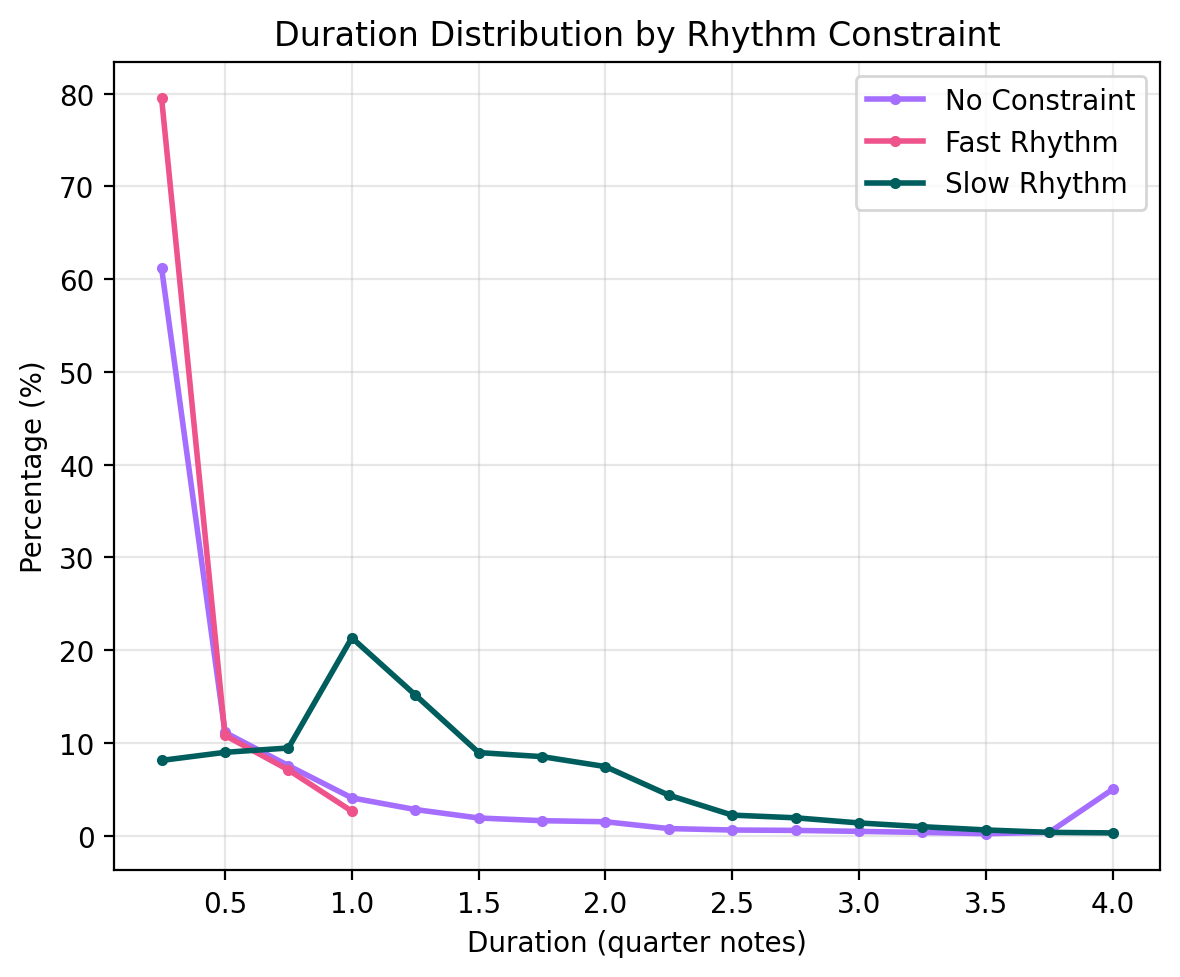

In [92]:
baseline_counts = Counter([d for d in second_order_durations if d <= 4])
fast_counts = Counter(fast_durations)
slow_counts = Counter(slow_durations)

baseline_total = sum(baseline_counts.values())
fast_total = sum(fast_counts.values())
slow_total = sum(slow_counts.values())

fig, ax = plt.subplots(figsize=(6, 5))

durations1 = sorted(baseline_counts.keys())
durations2 = sorted(fast_counts.keys())
durations3 = sorted(slow_counts.keys())

ax.plot(durations1, [baseline_counts[d]/baseline_total*100 for d in durations1], 
        marker='.', color='#a56eff', linewidth=2, label='No Constraint')

ax.plot(durations2, [fast_counts[d]/fast_total*100 for d in durations2], 
        marker='.', color='#ee538b', linewidth=2, label='Fast Rhythm')

ax.plot(durations3, [slow_counts[d]/slow_total*100 for d in durations3], 
        marker='.', color='#005d5d', linewidth=2, label='Slow Rhythm')

ax.set_xlabel('Duration (quarter notes)')
ax.set_ylabel('Percentage (%)')
ax.set_title('Duration Distribution by Rhythm Constraint')
ax.legend()
ax.grid(alpha=0.3)
plt.savefig('../evaluation/duration_distribution_constraint.png', dpi=300, bbox_inches='tight')
plt.tight_layout()

## Feature Extraction Vector

In [52]:
def extract_rich_features_from_midi(file_path):
    """
    Parses a MIDI file and extracts rich musical features (Pitch, Rhythm, Harmony).
    """
    try:
        score = music21.converter.parse(file_path)
        
        folder_name = os.path.basename(os.path.dirname(file_path))
        parts = folder_name.split('_')
        genre = parts[0] if len(parts) > 0 else "Unknown"

        notes_and_chords = score.flat.notesAndRests
        pitches = []
        durations = []
        
        for element in notes_and_chords:
            if isinstance(element, music21.note.Note):
                pitches.append(element.pitch.midi)
                durations.append(element.duration.quarterLength)
            elif isinstance(element, music21.chord.Chord):
                pitches.append(element.root().midi) 
                durations.append(element.duration.quarterLength)
        if not pitches:
            return None

        avg_pitch = np.mean(pitches)
        pitch_std = np.std(pitches)
        pitch_range = max(pitches) - min(pitches)
        
        avg_duration = np.mean(durations)
        duration_std = np.std(durations)
        
        total_notes = len(pitches)
        duration_quarters = score.flat.highestTime
        note_density = total_notes / duration_quarters if duration_quarters > 0 else 0

        pcp = score.flat.pitchClassStrengths(sortBy='pitchClass').values()
        
        features = {
            'FileName': os.path.basename(file_path),
            'Genre': genre,
            'AvgPitch': avg_pitch,
            'PitchStd': pitch_std,
            'PitchRange': pitch_range,
            'AvgDuration': avg_duration,
            'DurationStd': duration_std,
            'NoteDensity': note_density,
        }
        
        for i, strength in enumerate(pcp):
            features[f'Chroma_{i}'] = strength
            
        return features

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


In [84]:
target_genres = ['classical', 'jazz', 'pop', 'nes'] 

suffix = '_root_second'

target_folders = [genre + suffix for genre in target_genres]

midi_directory_path = '../outputs/' 

all_midi_files = glob.glob(os.path.join(midi_directory_path, '**/*.mid'), recursive=True) + \
                 glob.glob(os.path.join(midi_directory_path, '**/*.midi'), recursive=True)

filtered_midi_files = []
for file_path in all_midi_files:
    folder_name = os.path.basename(os.path.dirname(file_path))
    
    if folder_name in target_folders:
        filtered_midi_files.append(file_path)

print(f"Found {len(all_midi_files)} total MIDI files in outputs directory.")
print(f"Processing {len(filtered_midi_files)} files from targeted folders: {target_folders}")

features_list = []
for file_path in filtered_midi_files:
    features = extract_features_from_midi(file_path) 
    if features:
        features_list.append(features)

df = pd.DataFrame(features_list)
df.head()

Found 2965 total MIDI files in outputs directory.
Processing 400 files from targeted folders: ['classical_root_second', 'jazz_root_second', 'pop_root_second', 'nes_root_second']


/home/meganexe/miniconda3/envs/cs4100/lib/python3.11/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)


,FileName,Genre,ChordStrategy,Order,AvgPitch,PitchRange,NoteDensity
0,1.mid,classical,root,second,63.045455,60,1.718750
1,10.mid,classical,root,second,59.945946,58,0.616667
2,100.mid,classical,root,second,62.990291,60,1.716667
3,11.mid,classical,root,second,64.079710,63,2.300000
4,12.mid,classical,root,second,61.273585,70,1.656250


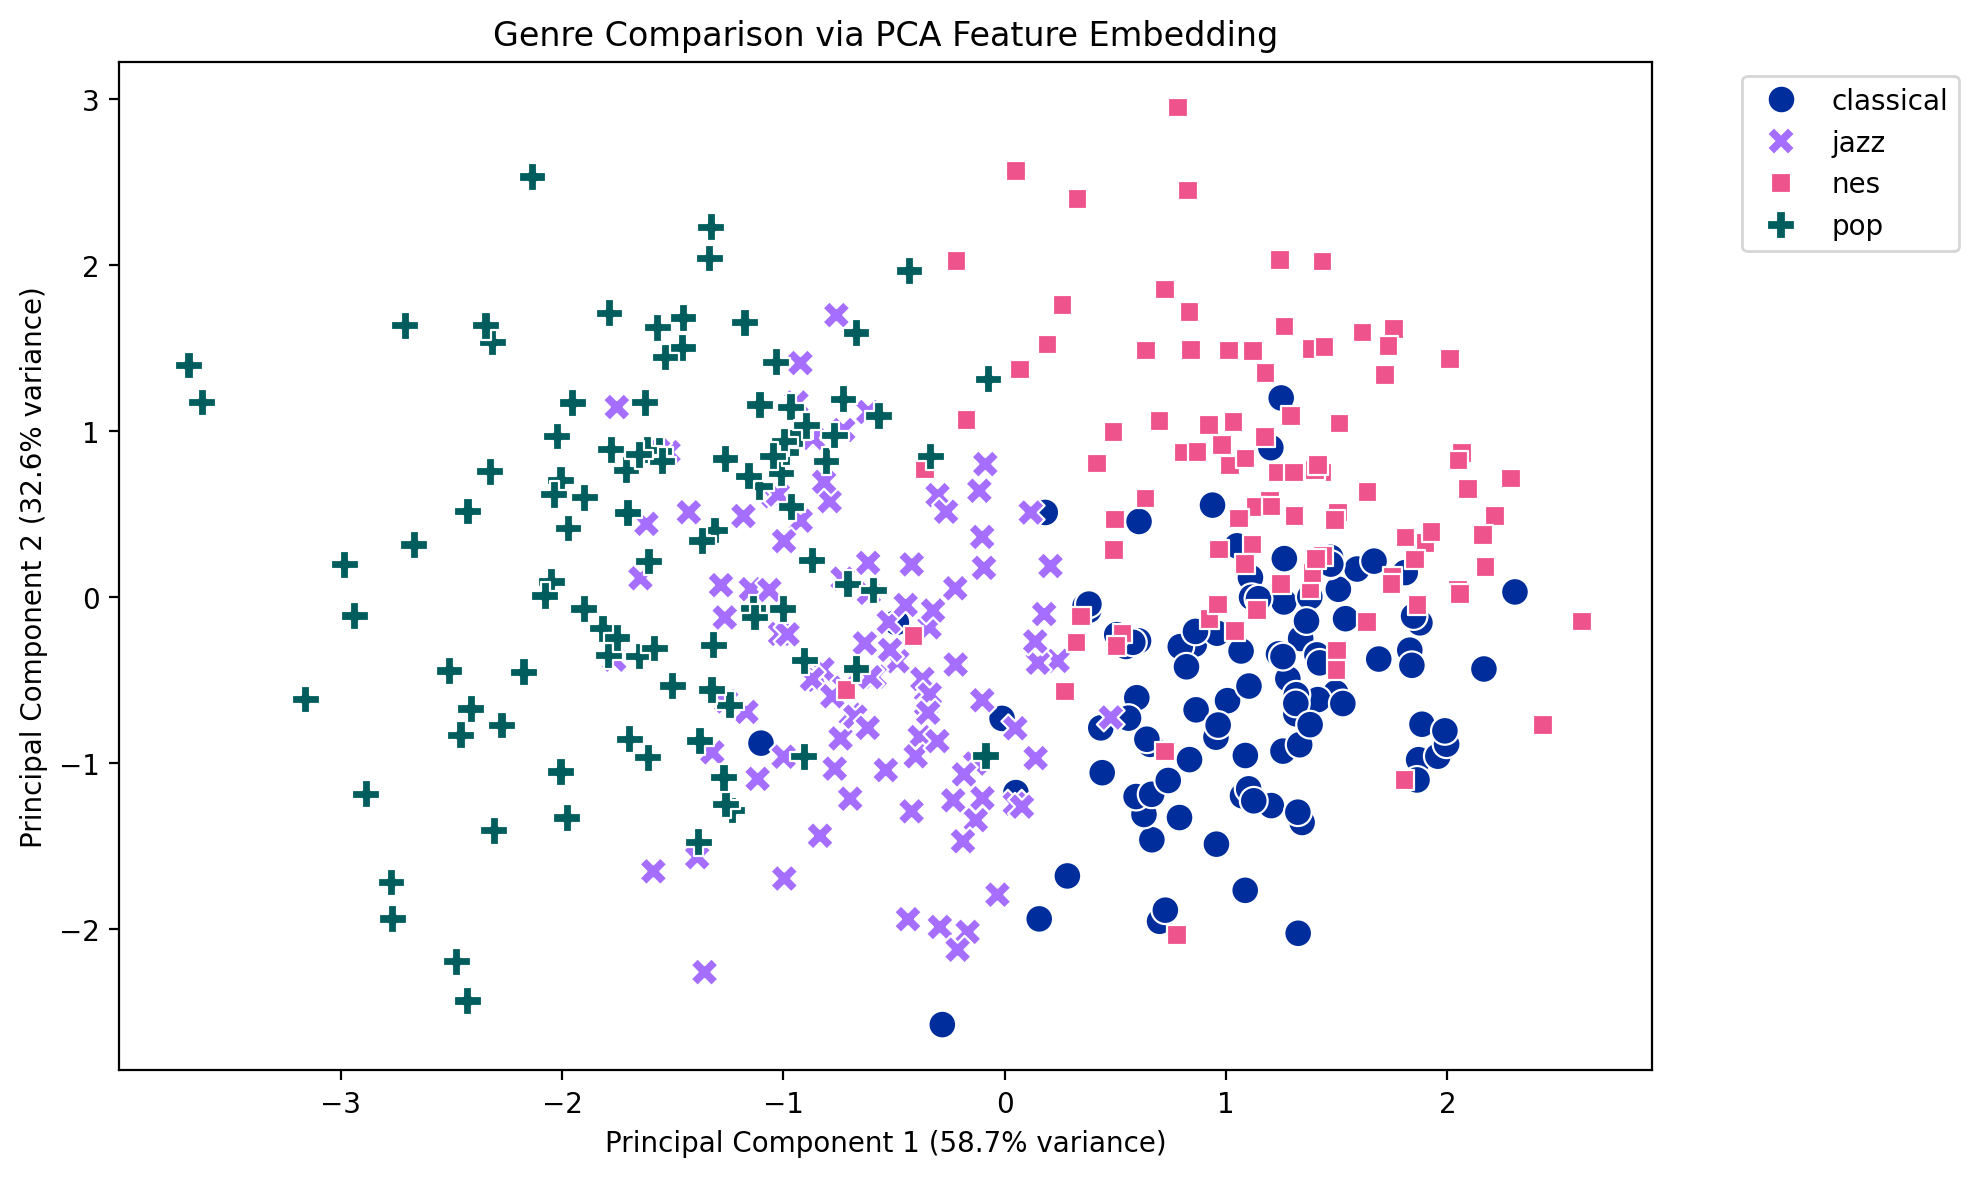

In [88]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

features_to_scale = df.drop(['FileName', 'Genre', 'ChordStrategy', 'Order'], axis=1, errors='ignore')

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_to_scale)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Genre'] = df['Genre'] 

palette = {
    'nes': '#ee538b',
    'jazz': '#a56eff',
    'classical': '#002d9c',
    'pop': '#005d5d'
}

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='Genre', 
    style='Genre', 
    palette=palette,
    s=100
)

plt.title('Genre Comparison via PCA Feature Embedding')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../evaluation/genre_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [89]:
target_moods = ['angry', 'exciting', 'warm', 'sad'] 

suffix = '_highest_second'

target_folders = [genre + suffix for genre in target_moods]

midi_directory_path = '../outputs/' 

all_midi_files = glob.glob(os.path.join(midi_directory_path, '**/*.mid'), recursive=True) + \
                 glob.glob(os.path.join(midi_directory_path, '**/*.midi'), recursive=True)

filtered_midi_files = []
for file_path in all_midi_files:
    folder_name = os.path.basename(os.path.dirname(file_path))
    
    if folder_name in target_folders:
        filtered_midi_files.append(file_path)

print(f"Found {len(all_midi_files)} total MIDI files in outputs directory.")
print(f"Processing {len(filtered_midi_files)} files from targeted folders: {target_folders}")

features_list = []
for file_path in filtered_midi_files:
    features = extract_features_from_midi(file_path) 
    if features:
        features_list.append(features)

df = pd.DataFrame(features_list)
df.head()

Found 2965 total MIDI files in outputs directory.
Processing 400 files from targeted folders: ['angry_highest_second', 'exciting_highest_second', 'warm_highest_second', 'sad_highest_second']


/home/meganexe/miniconda3/envs/cs4100/lib/python3.11/site-packages/music21/stream/base.py:3675: Music21DeprecationWarning: .flat is deprecated.  Call .flatten() instead
  return self.iter().getElementsByClass(classFilterList)


,FileName,Genre,ChordStrategy,Order,AvgPitch,PitchRange,NoteDensity
0,1.mid,angry,highest,second,47.739130,58,1.916667
1,10.mid,angry,highest,second,51.943089,49,1.921875
2,100.mid,angry,highest,second,54.946970,49,2.200000
3,11.mid,angry,highest,second,48.617391,53,1.597222
4,12.mid,angry,highest,second,37.081301,46,2.050000


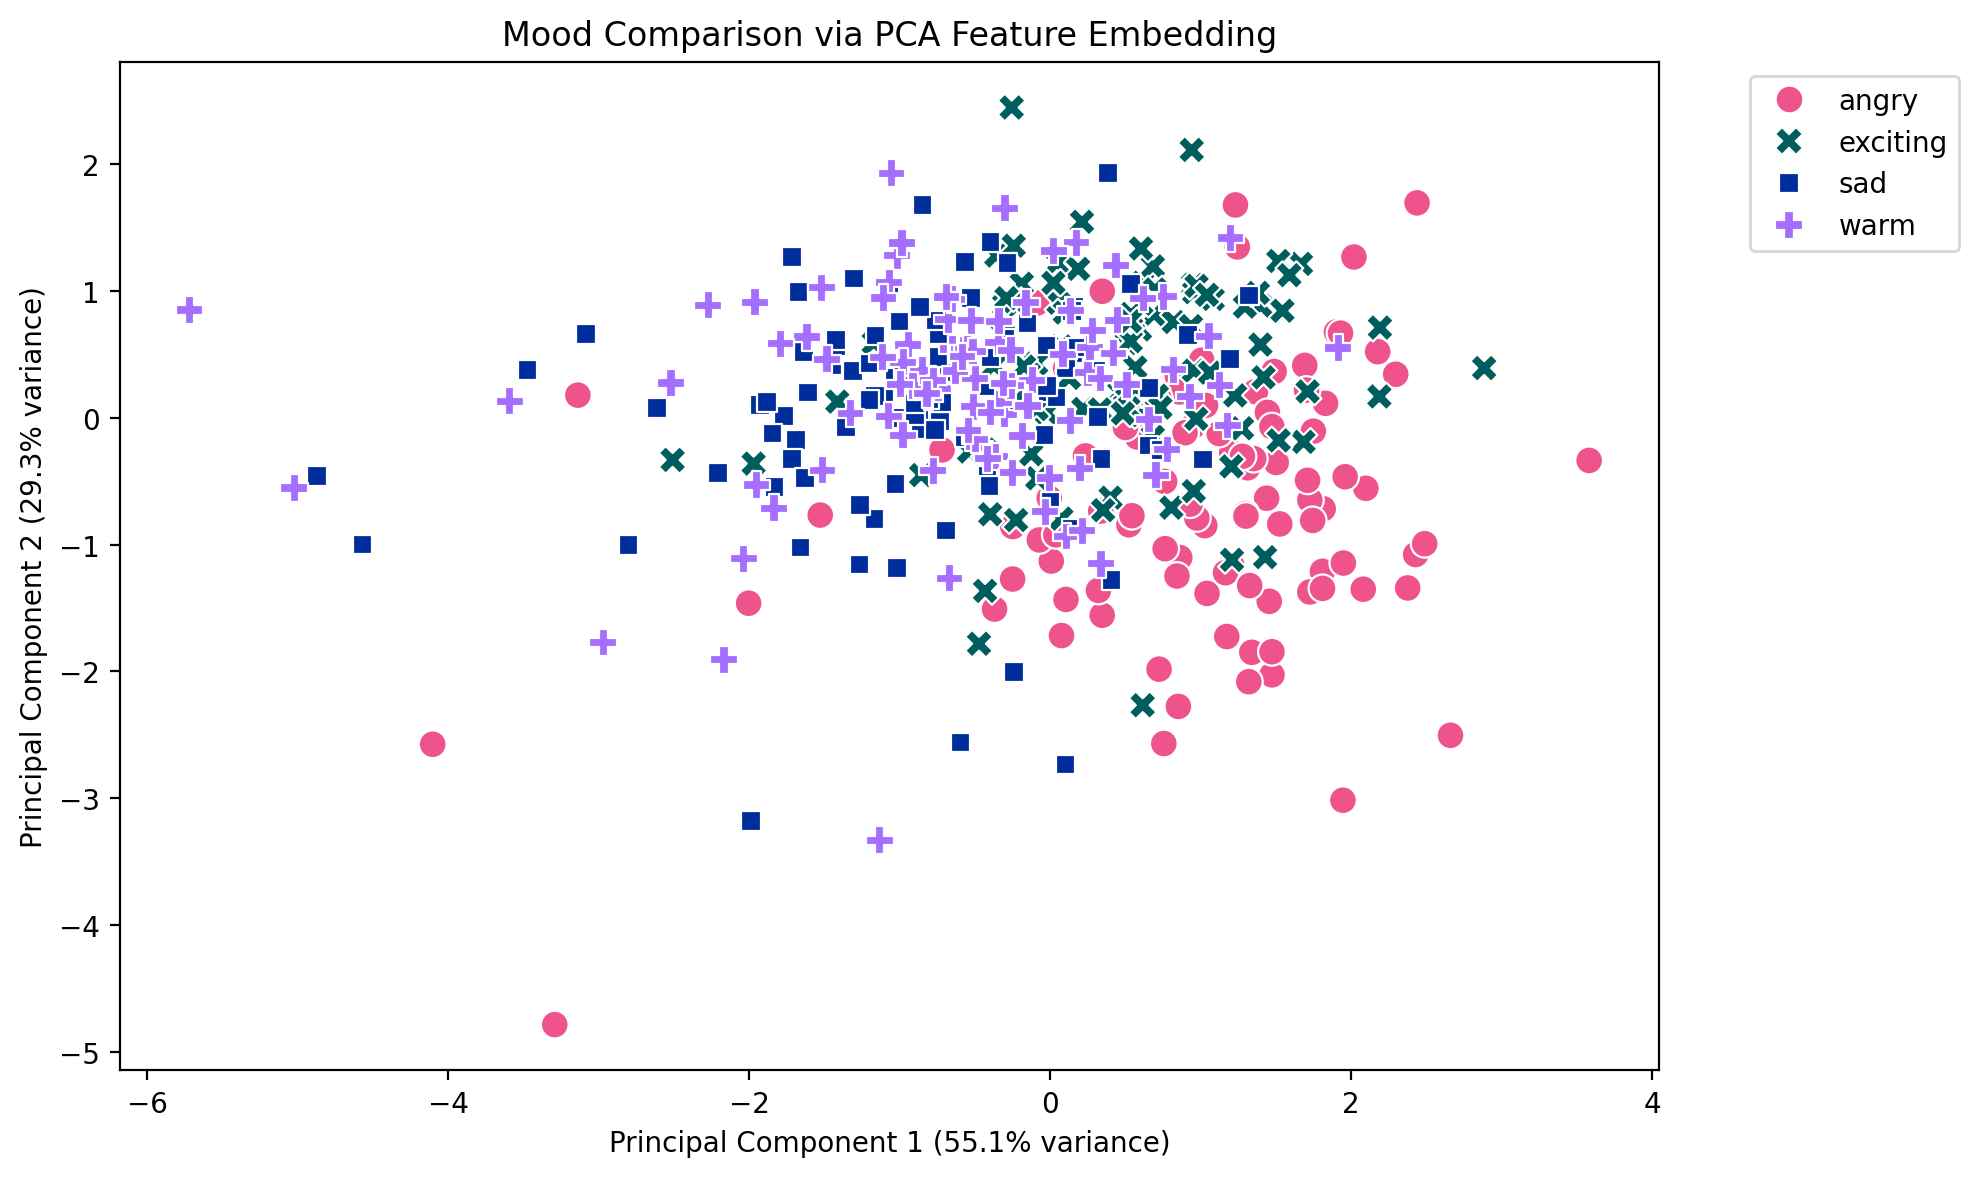

In [91]:
features_to_scale = df.drop(['FileName', 'Genre', 'ChordStrategy', 'Order'], axis=1, errors='ignore')

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_to_scale)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['Genre'] = df['Genre'] 

palette = {
    'angry': '#ee538b',
    'warm': '#a56eff',
    'sad': '#002d9c',
    'exciting': '#005d5d'
}

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df, 
    x='PC1', 
    y='PC2', 
    hue='Genre', 
    style='Genre', 
    palette=palette,
    s=100
)

plt.title('Mood Comparison via PCA Feature Embedding')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../evaluation/mood_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [59]:
classical_orig_pitches, classical_orig_durations, classical_orig_intervals = extract_data('../data/raw/classical', max_files=50)

orig_avg_pitch = np.mean(classical_orig_pitches)
orig_pitch_range = max(classical_orig_pitches) - min(classical_orig_pitches)
orig_avg_duration = np.mean(classical_orig_durations)
orig_note_density = len(classical_orig_pitches) / sum(classical_orig_durations)

classical_gen_pitches, classical_gen_durations, classical_gen_intervals = extract_data('../outputs/classical_highest_second/', max_files=50)

gen_avg_pitch = np.mean(classical_gen_pitches)
gen_pitch_range = max(classical_gen_pitches) - min(classical_gen_pitches)
gen_avg_duration = np.mean(classical_gen_durations)
gen_note_density = len(classical_gen_pitches) / sum(classical_gen_durations)

classical_distance = np.sqrt(
    (orig_avg_pitch - gen_avg_pitch)**2 +
    (orig_pitch_range - gen_pitch_range)**2 +
    (orig_avg_duration - gen_avg_duration)**2 +
    (orig_note_density - gen_note_density)**2
)

print(f"Classical distance: {classical_distance}")

Classical distance: 4.083687297407216


In [60]:
classical_orig_pitches, classical_orig_durations, classical_orig_intervals = extract_data('../data/raw/jazz', max_files=50)

orig_avg_pitch = np.mean(classical_orig_pitches)
orig_pitch_range = max(classical_orig_pitches) - min(classical_orig_pitches)
orig_avg_duration = np.mean(classical_orig_durations)
orig_note_density = len(classical_orig_pitches) / sum(classical_orig_durations)

classical_gen_pitches, classical_gen_durations, classical_gen_intervals = extract_data('../outputs/jazz_highest_second/', max_files=50)

gen_avg_pitch = np.mean(classical_gen_pitches)
gen_pitch_range = max(classical_gen_pitches) - min(classical_gen_pitches)
gen_avg_duration = np.mean(classical_gen_durations)
gen_note_density = len(classical_gen_pitches) / sum(classical_gen_durations)

jazz_distance = np.sqrt(
    (orig_avg_pitch - gen_avg_pitch)**2 +
    (orig_pitch_range - gen_pitch_range)**2 +
    (orig_avg_duration - gen_avg_duration)**2 +
    (orig_note_density - gen_note_density)**2
)

print(f"Jazz distance: {jazz_distance}")

Jazz distance: 2.080515663698467


In [61]:
classical_orig_pitches, classical_orig_durations, classical_orig_intervals = extract_data('../data/raw/pop', max_files=50)

orig_avg_pitch = np.mean(classical_orig_pitches)
orig_pitch_range = max(classical_orig_pitches) - min(classical_orig_pitches)
orig_avg_duration = np.mean(classical_orig_durations)
orig_note_density = len(classical_orig_pitches) / sum(classical_orig_durations)

classical_gen_pitches, classical_gen_durations, classical_gen_intervals = extract_data('../outputs/pop_highest_second/', max_files=50)

gen_avg_pitch = np.mean(classical_gen_pitches)
gen_pitch_range = max(classical_gen_pitches) - min(classical_gen_pitches)
gen_avg_duration = np.mean(classical_gen_durations)
gen_note_density = len(classical_gen_pitches) / sum(classical_gen_durations)

pop_distance = np.sqrt(
    (orig_avg_pitch - gen_avg_pitch)**2 +
    (orig_pitch_range - gen_pitch_range)**2 +
    (orig_avg_duration - gen_avg_duration)**2 +
    (orig_note_density - gen_note_density)**2
)

print(f"Pop distance: {pop_distance}")

Pop distance: 18.421941468619252


In [62]:
classical_orig_pitches, classical_orig_durations, classical_orig_intervals = extract_data('../data/raw/nes', max_files=50)

orig_avg_pitch = np.mean(classical_orig_pitches)
orig_pitch_range = max(classical_orig_pitches) - min(classical_orig_pitches)
orig_avg_duration = np.mean(classical_orig_durations)
orig_note_density = len(classical_orig_pitches) / sum(classical_orig_durations)

classical_gen_pitches, classical_gen_durations, classical_gen_intervals = extract_data('../outputs/nes_highest_second/', max_files=50)

gen_avg_pitch = np.mean(classical_gen_pitches)
gen_pitch_range = max(classical_gen_pitches) - min(classical_gen_pitches)
gen_avg_duration = np.mean(classical_gen_durations)
gen_note_density = len(classical_gen_pitches) / sum(classical_gen_durations)

nes_distance = np.sqrt(
    (orig_avg_pitch - gen_avg_pitch)**2 +
    (orig_pitch_range - gen_pitch_range)**2 +
    (orig_avg_duration - gen_avg_duration)**2 +
    (orig_note_density - gen_note_density)**2
)

print(f"NES distance: {nes_distance}")

NES distance: 10.813184336186712


In [76]:
classical_orig_pitches, classical_orig_durations, classical_orig_intervals = extract_data('../data/raw/angry', max_files=50)

orig_avg_pitch = np.mean(classical_orig_pitches)
orig_pitch_range = max(classical_orig_pitches) - min(classical_orig_pitches)
orig_avg_duration = np.mean(classical_orig_durations)
orig_note_density = len(classical_orig_pitches) / sum(classical_orig_durations)

classical_gen_pitches, classical_gen_durations, classical_gen_intervals = extract_data('../outputs/angry_highest_second/', max_files=50)

gen_avg_pitch = np.mean(classical_gen_pitches)
gen_pitch_range = max(classical_gen_pitches) - min(classical_gen_pitches)
gen_avg_duration = np.mean(classical_gen_durations)
gen_note_density = len(classical_gen_pitches) / sum(classical_gen_durations)

angry_distance = np.sqrt(
    (orig_avg_pitch - gen_avg_pitch)**2 +
    (orig_pitch_range - gen_pitch_range)**2 +
    (orig_avg_duration - gen_avg_duration)**2 +
    (orig_note_density - gen_note_density)**2
)

print(f"Angry distance: {angry_distance}")

Angry distance: 17.288956072175814


In [77]:
classical_orig_pitches, classical_orig_durations, classical_orig_intervals = extract_data('../data/raw/sad', max_files=50)

orig_avg_pitch = np.mean(classical_orig_pitches)
orig_pitch_range = max(classical_orig_pitches) - min(classical_orig_pitches)
orig_avg_duration = np.mean(classical_orig_durations)
orig_note_density = len(classical_orig_pitches) / sum(classical_orig_durations)

classical_gen_pitches, classical_gen_durations, classical_gen_intervals = extract_data('../outputs/sad_highest_second/', max_files=50)

gen_avg_pitch = np.mean(classical_gen_pitches)
gen_pitch_range = max(classical_gen_pitches) - min(classical_gen_pitches)
gen_avg_duration = np.mean(classical_gen_durations)
gen_note_density = len(classical_gen_pitches) / sum(classical_gen_durations)

sad_distance = np.sqrt(
    (orig_avg_pitch - gen_avg_pitch)**2 +
    (orig_pitch_range - gen_pitch_range)**2 +
    (orig_avg_duration - gen_avg_duration)**2 +
    (orig_note_density - gen_note_density)**2
)

print(f"Sad distance: {sad_distance}")

Sad distance: 22.03097497831192


In [78]:
classical_orig_pitches, classical_orig_durations, classical_orig_intervals = extract_data('../data/raw/warm', max_files=50)

orig_avg_pitch = np.mean(classical_orig_pitches)
orig_pitch_range = max(classical_orig_pitches) - min(classical_orig_pitches)
orig_avg_duration = np.mean(classical_orig_durations)
orig_note_density = len(classical_orig_pitches) / sum(classical_orig_durations)

classical_gen_pitches, classical_gen_durations, classical_gen_intervals = extract_data('../outputs/warm_highest_second/', max_files=50)

gen_avg_pitch = np.mean(classical_gen_pitches)
gen_pitch_range = max(classical_gen_pitches) - min(classical_gen_pitches)
gen_avg_duration = np.mean(classical_gen_durations)
gen_note_density = len(classical_gen_pitches) / sum(classical_gen_durations)

warm_distance = np.sqrt(
    (orig_avg_pitch - gen_avg_pitch)**2 +
    (orig_pitch_range - gen_pitch_range)**2 +
    (orig_avg_duration - gen_avg_duration)**2 +
    (orig_note_density - gen_note_density)**2
)

print(f"Warm distance: {warm_distance}")

Warm distance: 9.245954475154544


In [79]:
classical_orig_pitches, classical_orig_durations, classical_orig_intervals = extract_data('../data/raw/exciting', max_files=50)

orig_avg_pitch = np.mean(classical_orig_pitches)
orig_pitch_range = max(classical_orig_pitches) - min(classical_orig_pitches)
orig_avg_duration = np.mean(classical_orig_durations)
orig_note_density = len(classical_orig_pitches) / sum(classical_orig_durations)

classical_gen_pitches, classical_gen_durations, classical_gen_intervals = extract_data('../outputs/exciting_highest_second/', max_files=50)

gen_avg_pitch = np.mean(classical_gen_pitches)
gen_pitch_range = max(classical_gen_pitches) - min(classical_gen_pitches)
gen_avg_duration = np.mean(classical_gen_durations)
gen_note_density = len(classical_gen_pitches) / sum(classical_gen_durations)

exciting_distance = np.sqrt(
    (orig_avg_pitch - gen_avg_pitch)**2 +
    (orig_pitch_range - gen_pitch_range)**2 +
    (orig_avg_duration - gen_avg_duration)**2 +
    (orig_note_density - gen_note_density)**2
)

print(f"Exciting distance: {exciting_distance}")

Exciting distance: 6.6602045650872945


In [63]:
jazz_p, jazz_d, jazz_i = extract_data('../data/raw/jazz', max_files=50)
classical_p, classical_d, classical_i = extract_data('../data/raw/classical', max_files=50)
pop_p, pop_d, pop_i = extract_data('../data/raw/pop', max_files=50)
nes_p, nes_d, nes_i = extract_data('../data/raw/nes', max_files=50)

all_orig_pitches = jazz_p + classical_p + pop_p + nes_p
all_orig_durations = jazz_d + classical_d + pop_d + nes_d

orig_avg_pitch = np.mean(all_orig_pitches)
orig_pitch_range = max(all_orig_pitches) - min(all_orig_pitches)
orig_avg_duration = np.mean(all_orig_durations)
orig_note_density = len(all_orig_pitches) / sum(all_orig_durations)

# Get generated all-genres data
all_gen_pitches, all_gen_durations, all_gen_intervals = extract_data('../outputs/classical_jazz_nes_pop_highest_second/', max_files=50)

gen_avg_pitch = np.mean(all_gen_pitches)
gen_pitch_range = max(all_gen_pitches) - min(all_gen_pitches)
gen_avg_duration = np.mean(all_gen_durations)
gen_note_density = len(all_gen_pitches) / sum(all_gen_durations)

# Calculate distance
all_distance = np.sqrt(
    (orig_avg_pitch - gen_avg_pitch)**2 +
    (orig_pitch_range - gen_pitch_range)**2 +
    (orig_avg_duration - gen_avg_duration)**2 +
    (orig_note_density - gen_note_density)**2
)

print(f"All-genres distance: {all_distance}")

All-genres distance: 4.279481439526152


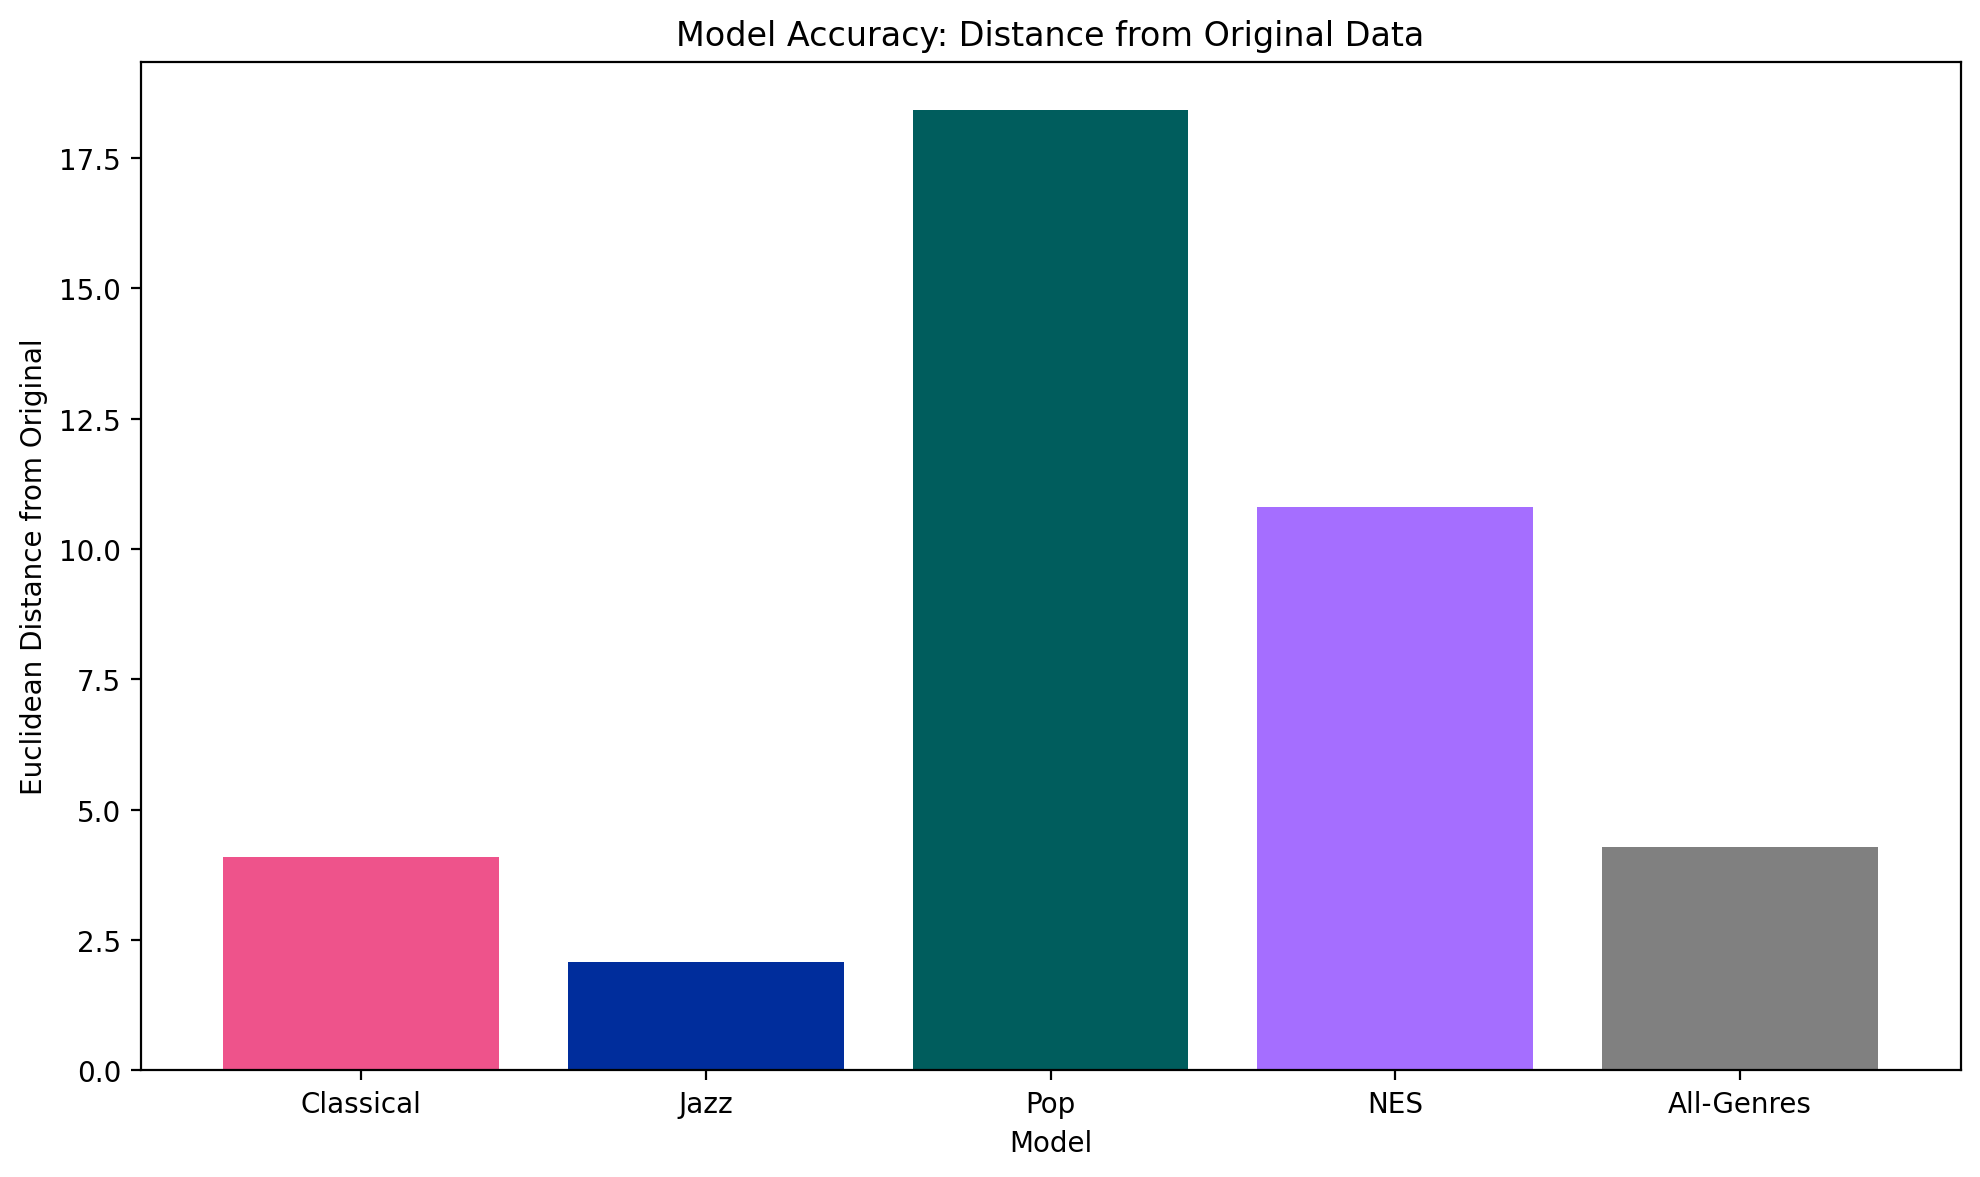

In [82]:
models = ['Classical', 'Jazz', 'Pop', 'NES', 'All-Genres']
distances = [classical_distance, jazz_distance, pop_distance, nes_distance, all_distance]

plt.figure(figsize=(10, 6))
plt.bar(models, distances, color=['#ee538b', '#002d9c', '#005d5d', '#a56eff', '#808080'])
plt.ylabel('Euclidean Distance from Original')
plt.xlabel('Model')
plt.title('Model Accuracy: Distance from Original Data')
plt.savefig('../evaluation/genre_to_original.png', dpi=300, bbox_inches='tight')
plt.tight_layout()